In [1]:
import os
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import torch
import argparse
from nnfabrik.builder import get_data, get_trainer

from modified_neuralpredictors.create_model import stacked_core_full_gauss_readout
from modified_neuralpredictors.wandb_trainer import standard_trainer

random_seed = 42
torch.manual_seed(random_seed)
np.random.seed(random_seed)

device = 'cuda:0'
torch.cuda.set_device(device)

basepath = "/srv/user/polina/sensorium/sensorium/notebooks/data/"

# as filenames, we'll select all 7 datasets
filenames = [
    os.path.join(basepath, file) for file in os.listdir(basepath) if ".zip" in file
]

dataset_fn = "sensorium.datasets.static_loaders"
dataset_config = {
    "paths": filenames,
    "normalize": True,
    "include_behavior": True,
    "include_eye_position": True,
    "batch_size": 128,
    "scale": 0.25,
}

dataloaders = get_data(dataset_fn, dataset_config)
data_keys = list(dataloaders['train'].keys())

model_config = {
    'hidden_channels': 64, # original sensorium was 64ch
    'depth_separable': False,
    'use_avg_reg': False,
    'laplace_padding': None,
    'momentum': 0.75,
    'final_nonlinearity': True,
    'nonlinearity_type': 'AdaptiveELU',
    'pad_input': False,
    'stack': -1,
    'layers': 4,
    'input_kern': 11, #  original sensorium was 'input_kern': 9,
    'gamma_input': 6.3831, # this should not influence the performance based on previous experience
    
    'feature_reg_weight': 3, # this is the one I actually would like to tune!
    
    'hidden_kern': 7,
    'grid_mean_predictor': {
        'type': 'cortex',
        'input_dimensions': 2,
        'hidden_layers': 1,
        'hidden_features': 30,
        'final_tanh': True
    },
    
    'init_sigma': 0.1,
    'init_mu_range': 0.3,
    'gauss_type': 'full',
    'shifter': True,
    'batch_norm_scale': [True, True, True, False],
    'core_bias': [True, True, True, False],
    'regularizer_type': "adaptive_log_norm",
    'gamma_sigma' : 0.25,
}

model = stacked_core_full_gauss_readout(dataloaders, random_seed, **model_config)
model.to(device);
model.train()

Passed `batch_norm_scale` as an iterable, ignoring `final_batchnorm_scale`.
/srv/user/nathanpaul.soeding/neuralpredictors/neuralpredictors/layers/readouts/base.py:95: UserWarning: Readout is NOT initialized with mean activity but with 0!
  warnings.warn("Readout is NOT initialized with mean activity but with 0!")


FiringRateEncoder(
  (core): Stacked2dCore(
    (_input_weights_regularizer): LaplaceL2norm(
      (laplace): Laplace()
    )
    (features): Sequential(
      (layer0): Sequential(
        (conv): Conv2d(4, 64, kernel_size=(11, 11), stride=(1, 1), bias=False)
        (norm): BatchNorm2d(64, eps=1e-05, momentum=0.75, affine=True, track_running_stats=True)
        (nonlin): AdaptiveELU()
      )
      (layer1): Sequential(
        (conv): Conv2d(64, 64, kernel_size=(7, 7), stride=(1, 1), padding=(3, 3))
        (norm): BatchNorm2d(64, eps=1e-05, momentum=0.75, affine=True, track_running_stats=True)
        (nonlin): AdaptiveELU()
      )
      (layer2): Sequential(
        (conv): Conv2d(64, 64, kernel_size=(7, 7), stride=(1, 1), padding=(3, 3))
        (norm): BatchNorm2d(64, eps=1e-05, momentum=0.75, affine=True, track_running_stats=True)
        (nonlin): AdaptiveELU()
      )
      (layer3): Sequential(
        (conv): Conv2d(64, 64, kernel_size=(7, 7), stride=(1, 1), padding=(3, 3)

In [2]:
paths = [
    'runs/newbase/dim64_seed0/model_weights.pth',
    'runs/newbase/dim64_seed42/model_weights.pth',
    'runs/newbase/dim64_seed123/model_weights.pth',
]

In [3]:
from sklearn.neighbors import NearestNeighbors
from sklearn.cluster import KMeans
from sklearn.metrics import adjusted_rand_score

def knn_consistency(knn1, knn2, ks):
    N, k_max = knn1.shape
    #idcs = torch.randperm(N)
    #knn2 = knn2[idcs]
    
    assert ks[-1] <= k_max 
    ranking = np.full((N, N), N, dtype=np.int32)  # Shape (N, N)
    ranking[np.arange(N)[:, None], knn1] = np.arange(k_max)[None]
    overlaps = []

    for k in ks:
        neighbours = knn2[:, :k]  # Shape (N, k)
        shared = ranking[np.arange(N)[:, None], neighbours] < k  # Shape (N, k)
        num_shared = shared.sum() / N
        
        overlap = num_shared / k
        overlaps.append(overlap)

    return np.array(overlaps)

def get_curve(k_range, all_features):
    knns = []
    for features in all_features:
        nn = NearestNeighbors(n_neighbors=k_range[-1]).fit(features)
        knn = nn.kneighbors(return_distance=False)
        knns.append(knn)

    #for leniency in leniency_range:
    x_idcs, y_idcs = np.tril_indices(len(all_features), k=-1)
    constistencies = []
    for x, y in zip(x_idcs, y_idcs):
        constistencies.append(knn_consistency(knns[x], knns[y], ks=k_range))
    constistencies = np.column_stack(constistencies)

    mean_curve = constistencies.mean(axis=1)
    std_curve = constistencies.std(axis=1, ddof=1)

    return mean_curve, std_curve

def get_ari_curve(n_clusters_range, all_features):
    def cluster(points, n_clusters):
        kmeans = KMeans(n_clusters=n_clusters, random_state=42)
        labels = kmeans.fit_predict(points)
        return labels
    
    mean_curve = []
    std_curve = []
    for n in n_clusters_range:
        labels = [cluster(features, n) for features in all_features]

        x_idcs, y_idcs = np.tril_indices(len(all_features), k=-1)
        aris = np.array([
            adjusted_rand_score(labels[x], labels[y]) for x, y in zip(x_idcs, y_idcs)
        ])

        ari_mean = aris.mean()
        ari_std = aris.std(ddof=1)
        mean_curve.append(ari_mean)
        std_curve.append(ari_std)
    
    return mean_curve, std_curve

In [4]:
ds = [32, 40, 48, 56, 64]
k_range = np.unique(np.geomspace(1, 100, num=10, dtype=int))
base_curves = []

for d in ds:
    compressed = []

    for path in paths:
        model.load_state_dict(torch.load(path, map_location=device))
        readouts = torch.cat([model.readout[key]._features.detach().cpu().squeeze().T for key in data_keys])

        readouts_c = readouts - readouts.mean(dim=0, keepdim=True)
        _, _, Vt = torch.linalg.svd(readouts_c, full_matrices=False)

        compressed.append(readouts @ Vt[:d].T)

    base_curves.append(get_curve(k_range, compressed))

In [5]:
Rws = []
Vts = []
num_batches = 10

for path in paths:
    model.load_state_dict(torch.load(path, map_location=device))
    feature_vecs = []
    readout_vecs = []

    for key in data_keys:
        single_vecs = []

        batch_count = 0
        for batch in dataloaders['train'][key]:
            batch_count += 1
            img, target, _, pupil = batch
            
            pred, feature_vec = model(img, data_key=key, pupil_center=pupil)
            single_vecs.append(feature_vec.detach().cpu())
            if batch_count == num_batches:
                break
            
        feature_vecs.append(torch.cat(single_vecs))
        readout_vecs.append(model.readout[key]._features.detach().cpu())

    X = torch.cat([vecs.permute(0, 2, 3, 1).flatten(0, 2) for vecs in feature_vecs])

    # compute cov
    mu = X.mean(dim=0, keepdims=True)
    Xc = X - mu
    cov = Xc.T @ Xc / (Xc.shape[0] - 1)

    # get whitening matrix from cov
    L = torch.linalg.cholesky(cov)
    Winv = L.T
    
    R = torch.cat([r.squeeze() for r in readout_vecs], dim=1)
    Rw = (Winv @ R).T

    Rwc = Rw - Rw.mean(dim=0, keepdims=True)
    _, _, Vt = torch.linalg.svd(Rwc, full_matrices=False)
    Rws.append(Rw)
    Vts.append(Vt)

In [6]:
ds = [32, 40, 48, 56, 64]
k_range = np.unique(np.geomspace(1, 100, num=10, dtype=int))
whitened_curves = []

for d in ds:
    compressed = []

    for Rw, Vt in zip(Rws, Vts):
        compressed.append(Rw @ Vt[:d].T)

    whitened_curves.append(get_curve(k_range, compressed))

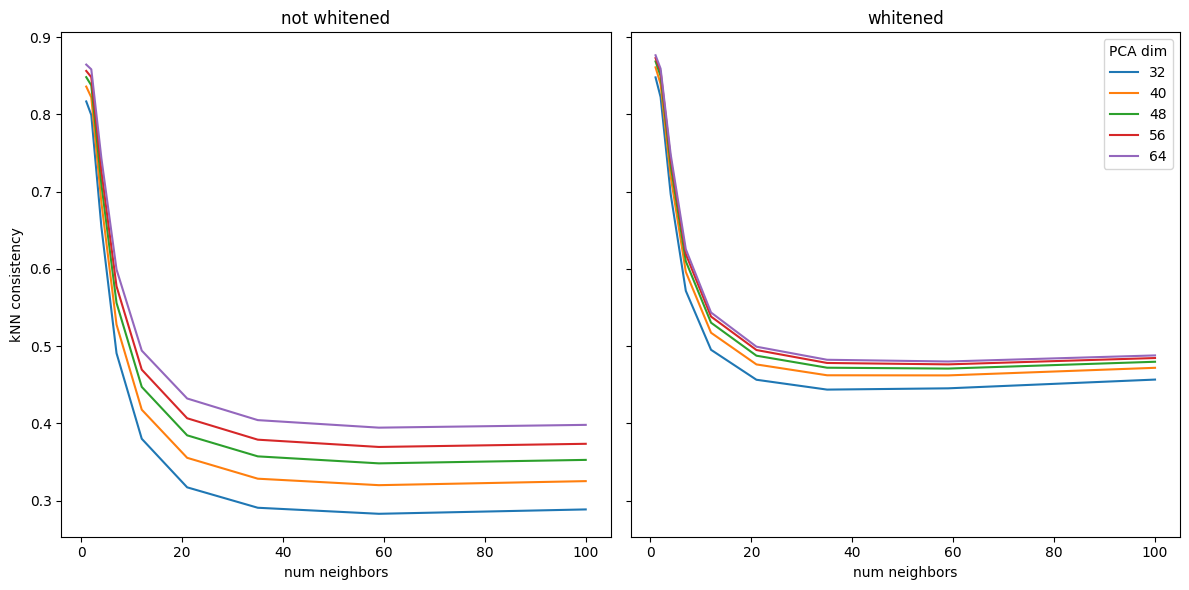

In [8]:
fig, ax = plt.subplots(1, 2, figsize=(12, 6), sharey=True)

for curve, d in zip(base_curves, ds):
    ax[0].plot(k_range, curve[0], label=d)

ax[0].set_title('not whitened')
ax[0].set_xlabel('num neighbors')
ax[0].set_ylabel('kNN consistency')

for curve, d in zip(whitened_curves, ds):
    ax[1].plot(k_range, curve[0], label=d)

ax[1].set_title('whitened')
ax[1].legend(title='PCA dim')
ax[1].set_xlabel('num neighbors')
plt.tight_layout()
plt.show()